In [7]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import maptools
import os

import matplotlib.pyplot as plt
import h5py

maptools.job.info()
maptools.plot.dark()
!which python

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
hostname: offline-fe1
SLURM_JOB_ID: None
SLURM_JOB_NODELIST: None
NPROCS: 40
Memory available: 50.255429632 GB
~/.conda/envs/grainmapper/bin/python


In [10]:
# Good scanning 3dxrd files are:
scans = maptools.constants.SCANRANGES
sample = "al1050_15pct_center_slice"
dataset = "scan-0053.h5"
dataroot = maptools.paths.RAW
analysisroot = os.path.join(maptools.paths.PROCESS, sample)
datapath = os.path.join(dataroot, sample, dataset)
maskfile = maptools.constants.PILATUS_MASK

In [9]:
maptools.io.check_metadata(datapath)
number_of_dty_scans_in_file = maptools.io.get_number_of_dty_scans_in_file(datapath)
frames = maptools.io.get_frames(datapath)
omega = maptools.io.get_omega(datapath)
dty = maptools.io.get_dty(datapath)
omsteps_per_scan = maptools.constants.NUMBER_OF_OMEGA_STEPS

number of dty scans in file: 17
number of omega steps per dty scan: 3003
number of frames in file: 51051
Detector shape: (1679, 1475)


bgfile None
threshold 4
smoothsigma 0.0
bgc 0.0
minpx 1
m_offset_thresh 0
m_ratio_thresh 0


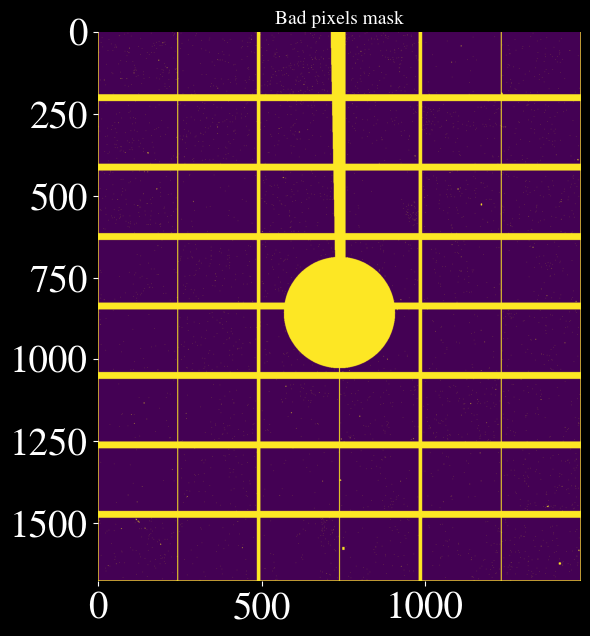

In [5]:
options = np.load("segmenter_options.npy", allow_pickle=True)[()]
for k in options.keys():
    if k != "maskfile":
        print(k, options[k])
plt.style.use("dark_background")
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
im = ax.imshow(options["maskfile"])
ax.set_title("Bad pixels mask", fontsize=14)
plt.tight_layout()
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

In [ ]:
# Test segementation to see how fast single dty segmentation is...
start_index = 0
end_index = 3003
pks = maptools.segmenter.segment_single_scan(
    frames, omega, dty[start_index], start_index, end_index, options, max_workers=40
)


  1%|▏         | 38/3003 [00:01<02:29, 19.85it/s]


KeyboardInterrupt: 

In [ ]:
pks_folder = os.path.join(maptools.paths.PROCESS, sample)
assert os.path.exists(pks_folder)

for _dataset in scans.keys():
    pksfile = os.path.join(
        maptools.paths.PROCESS, sample, "segmented_peaks_" + _dataset
    )
    raw_file = os.path.join(dataroot, sample, _dataset)

    with h5py.File(raw_file, "r") as f:
        frames = f["entry/measurement/pilatus"]
        print("frame array shape:", frames.shape)

    with h5py.File(raw_file, "r") as f:
        omega = f[maptools.paths.OMEGAMOTOR][:]
        dty = f[maptools.paths.DTYMOTOR][:]

    omsteps_per_scan = np.unique(omega.round(4)).size
    assert len(dty) % omsteps_per_scan == 0
    number_of_frames_in_file = frames.shape[0]

    number_of_dty_scans_in_file = len(dty) // omsteps_per_scan
    assert number_of_frames_in_file % number_of_dty_scans_in_file == 0
    assert number_of_frames_in_file // number_of_dty_scans_in_file == omsteps_per_scan

    indices = np.arange(0, len(frames) + 1, omsteps_per_scan)

    for i in range(number_of_dty_scans_in_file):
        assert np.allclose(
            dty[i * omsteps_per_scan : (i + 1) * omsteps_per_scan],
            dty[i * omsteps_per_scan],
        )

    print("\n######################################################################")
    print(raw_file)
    print(f"number of dty scans in file: {number_of_dty_scans_in_file}")
    print(f"number of omega steps per dty scan: {omsteps_per_scan}")
    print(f"number of frames in file: {number_of_frames_in_file}")
    print(f"Detector shape: {frames.shape[1:]}")
    print("######################################################################")

    for i in range(len(indices) - 1):
        start = indices[i]
        end = indices[i + 1]
        print(
            f"\n Segmenting frames in range {start} to {end} @ dty {np.round(dty[start] * 1000)} um"
        )

        pks = maptools.segmenter.segment_single_scan(
            frames, omega, dty[start], start, end, options, max_workers=44
        )

        v = np.round(dty[start] * 1000).astype(int)
        dty_key = f"dty_{v}_um" if v > 0 else f"dty_m{-v}_um"

        maptools.segmenter.write_pks_to_h5(
            pksfile,
            dty_key,
            pks,
            options,
            start,
            end,
            raw_file,
            overwrite=True,
        )


frame array shape: (51051, 1679, 1475)

######################################################################
/data/visitors/danmax/20251117/2025110808/raw/al1050_15pct_center_slice/scan-0048.h5
number of dty scans in file: 17
number of omega steps per dty scan: 3003
number of frames in file: 51051
Detector shape: (1679, 1475)
######################################################################

 Segmenting frames in range 0 to 3003 @ dty -750.0 um

 Segmenting frames in range 3003 to 6006 @ dty -740.0 um

 Segmenting frames in range 6006 to 9009 @ dty -730.0 um

 Segmenting frames in range 9009 to 12012 @ dty -720.0 um

 Segmenting frames in range 12012 to 15015 @ dty -710.0 um

 Segmenting frames in range 15015 to 18018 @ dty -700.0 um

 Segmenting frames in range 18018 to 21021 @ dty -690.0 um

 Segmenting frames in range 21021 to 24024 @ dty -680.0 um

 Segmenting frames in range 24024 to 27027 @ dty -670.0 um

 Segmenting frames in range 27027 to 30030 @ dty -660.0 um

 Segment